In [12]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


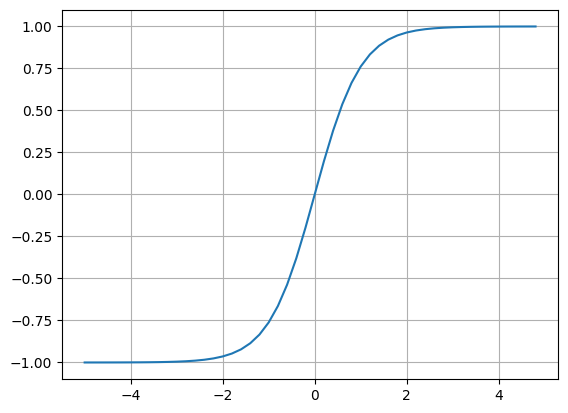

In [13]:
# tanh function

import random
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [14]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # We instantiate the constant
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        # other + self
        return self + other

    def __neg__(self):
        # -self
        return self * -1

    def __sub__(self, other):
        # self - other
        return self + (-other)

    def __mul__(self, other):
        # We instantiate the constant
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        # other * self
        return self * other

    def __truediv__(self, other):
        # self / other
        other = other if isinstance(other, Value) else Value(other)
        return self * (other ** -1)

    def __rtruediv__(self, other):
        # other / self
        other = other if isinstance(other, Value) else Value(other)
        return other * (self ** -1)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f"**{other}")
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

In [15]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x



In [27]:
n = MLP(3, [4, 4, 1])

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

# desired target
ys = [1.0, -1.0, -1.0, 1.0]

ypred = [n(x) for x in xs]
ypred

[Value(data=0.8315309129854104),
 Value(data=0.8605838237784801),
 Value(data=0.3595285413771524),
 Value(data=0.5120455084118384)]

In [28]:
# loss
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]


loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=5.576571439265829)

In [29]:
loss.backward()

In [30]:
n.layers[0].neurons[0].w[0]

Value(data=-0.5079796697758661)

In [31]:
n.layers[0].neurons[0].w[0].grad

0.3873655139720702

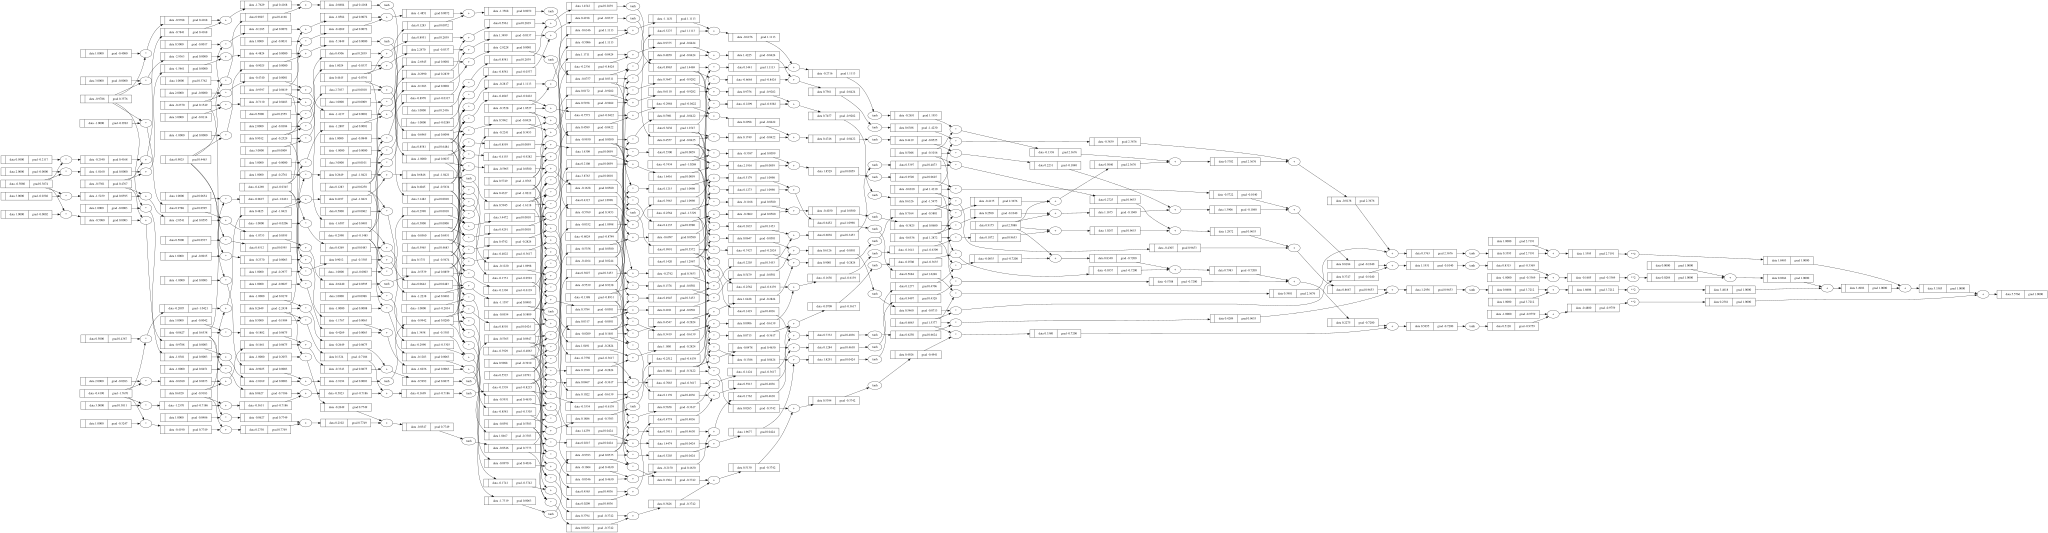

In [32]:
draw_dot(loss)

In [36]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # params = []
        # for neuron in self.neurons:
        #     ps = neurons.parameters()
        #     params.extend(ps)
        # return params
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [98]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.5389297807080131)

In [99]:
n.parameters()

[Value(data=0.3803204974623833),
 Value(data=-0.017703820822911),
 Value(data=-0.50157049523657),
 Value(data=-0.41521951427253057),
 Value(data=-0.467809987608542),
 Value(data=0.4103039192620872),
 Value(data=-0.258271021090253),
 Value(data=-0.3229575296461371),
 Value(data=-0.6184281002759635),
 Value(data=0.81967569985213),
 Value(data=0.20151013790200745),
 Value(data=-0.01006106686058561),
 Value(data=-0.9713396538545624),
 Value(data=0.5972090091057247),
 Value(data=-0.6065081969176465),
 Value(data=0.3866809137492695),
 Value(data=-0.5406485869048849),
 Value(data=-0.8286019745414228),
 Value(data=0.4297205250397129),
 Value(data=-0.1734651989817455),
 Value(data=0.993175616726665),
 Value(data=-0.8686597088639865),
 Value(data=-0.9946082295259526),
 Value(data=-0.8153985853377335),
 Value(data=0.6426517855910701),
 Value(data=-0.22964009760926363),
 Value(data=0.6930866811518956),
 Value(data=-0.5697377525582155),
 Value(data=0.1562624065157907),
 Value(data=-0.22151705206528

In [100]:
len(n.parameters())

41

In [101]:
n.layers[0].neurons[0].w[0].grad

0.0

In [102]:
n.layers[0].neurons[0].w[0].data

0.3803204974623833

In [103]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [104]:
loss.backward()

In [105]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.4358021877534073)

In [106]:
ypred

[Value(data=0.5389297807080131),
 Value(data=-0.07047902846630401),
 Value(data=-0.07958016238554999),
 Value(data=0.2844341213834399)]

In [107]:
for k in range(50):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

ypred

0 2.4358021877534073
1 1.1314987334791033
2 0.6075837781379747
3 0.38419087972706156
4 0.27250324877875565
5 0.2075935165997238
6 0.1659973029132037
7 0.13739721706229302
8 0.11667893706208424
9 0.10105864136599074
10 0.08890596449906298
11 0.07920882218130276
12 0.07130858155364307
13 0.06475961512047779
14 0.059250424462973156
15 0.05455716036887832
16 0.05051509169884029
17 0.047000466602414234
18 0.043918624293707326
19 0.041195993021637
20 0.038774575668363134
21 0.036608069348768896
22 0.03465908328031471
23 0.03289711022844852
24 0.03129702472793475
25 0.029837955802842646
26 0.028502430047831734
27 0.02727571265109329
28 0.026145295217613218
29 0.02510049376458712
30 0.024132130311744642
31 0.02323227854865665
32 0.022394059084321405
33 0.02161147340227449
34 0.020879268279844453
35 0.020192824370155592
36 0.019548064087707907
37 0.018941375020504022
38 0.01836954591074226
39 0.017829712871094573
40 0.017319313984220236
41 0.016836050805464905
42 0.016377855579086324
43 0.01594

[Value(data=0.9594792112847776),
 Value(data=-0.9592116711649966),
 Value(data=-0.9312440396300189),
 Value(data=0.9244829080197294)]